In [ ]:
!pip install -q datasets matplotlib pillow pandas

In [ ]:
from datasets import load_dataset

import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
import numpy as np

In [ ]:
from datasets import load_dataset

dataset = load_dataset(
    "jxie/flickr8k",
    split="train[:50]"
)

print("Dataset Loaded Successfully!")

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset Loaded Successfully!


In [ ]:
print(dataset)

Dataset({
    features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
    num_rows: 50
})


In [ ]:
sample = dataset[0]

print(sample.keys())

dict_keys(['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'])


In [ ]:
sample = dataset[0]

print(sample)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x399 at 0x7D17F2A9A8D0>, 'caption_0': 'A black dog is running after a white dog in the snow .', 'caption_1': 'Black dog chasing brown dog through snow', 'caption_2': 'Two dogs chase each other across the snowy ground .', 'caption_3': 'Two dogs play together in the snow .', 'caption_4': 'Two dogs running through a low lying body of water .'}


In [ ]:
print(sample)

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x399 at 0x7D17F2B1C470>, 'caption_0': 'A black dog is running after a white dog in the snow .', 'caption_1': 'Black dog chasing brown dog through snow', 'caption_2': 'Two dogs chase each other across the snowy ground .', 'caption_3': 'Two dogs play together in the snow .', 'caption_4': 'Two dogs running through a low lying body of water .'}


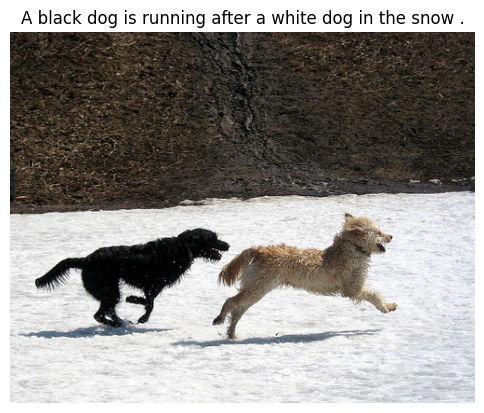

In [ ]:
sample = dataset[0]

image = sample['image']

caption = sample['caption_0']

image = image.convert("RGB")

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(image)

plt.title(caption)

plt.axis("off")

plt.show()

In [16]:
caption_lengths = []

for sample in dataset:

    caption = sample['caption_0']

    caption_lengths.append(
        len(caption.split())
    )

print("Average Caption Length:",
      np.mean(caption_lengths))

print("Maximum Caption Length:",
      np.max(caption_lengths))

print("Minimum Caption Length:",
      np.min(caption_lengths))

Average Caption Length: 12.44
Maximum Caption Length: 24
Minimum Caption Length: 5


In [17]:
image_sizes = []

for sample in dataset:

    image_sizes.append(
        sample['image'].size
    )

print("Sample Image Resolutions:")

for size in image_sizes[:5]:

    print(size)

Sample Image Resolutions:
(500, 399)
(300, 500)
(500, 333)
(500, 360)
(500, 333)


In [18]:
print("Dataset Statistics")
print("------------------")

print("Total Samples:",
      len(dataset))

print("Average Caption Length:",
      np.mean(caption_lengths))

print("Sample Resolution:",
      image_sizes[0])

Dataset Statistics
------------------
Total Samples: 50
Average Caption Length: 12.44
Sample Resolution: (500, 399)


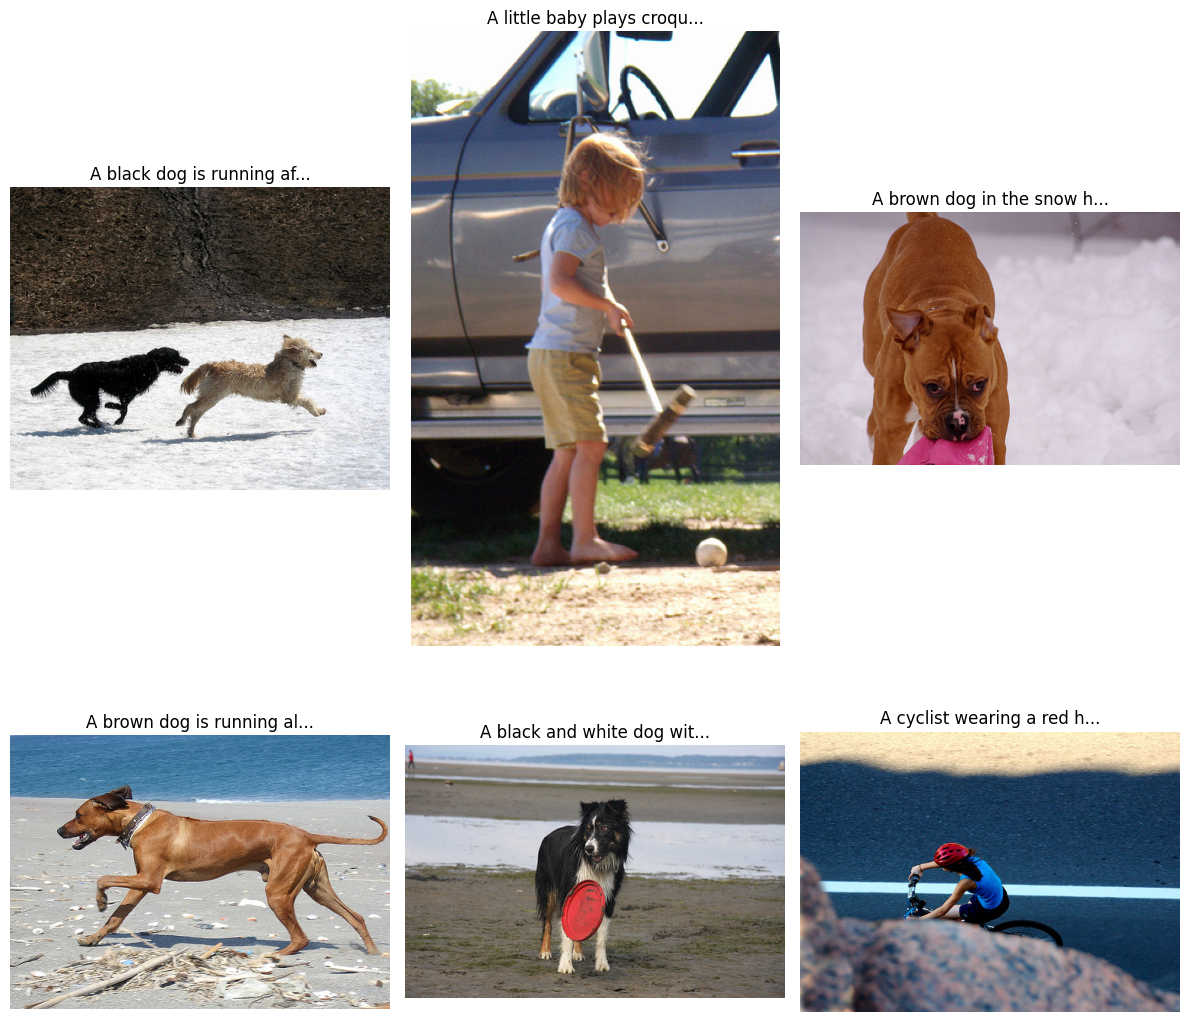

In [19]:
plt.figure(figsize=(12,12))

for i in range(6):

    sample = dataset[i]

    image = sample['image']

    caption = sample['caption_0']

    plt.subplot(2,3,i+1)

    plt.imshow(image)

    plt.title(caption[:25] + "...")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [20]:
dataset.save_to_disk("flickr8k_dataset")

Saving the dataset (0/1 shards):   0%|          | 0/50 [00:00<?, ? examples/s]

In [21]:
!zip -r flickr8k_dataset.zip flickr8k_dataset

  adding: flickr8k_dataset/ (stored 0%)
  adding: flickr8k_dataset/state.json (deflated 37%)
  adding: flickr8k_dataset/dataset_info.json (deflated 72%)
  adding: flickr8k_dataset/data-00000-of-00001.arrow (deflated 0%)
